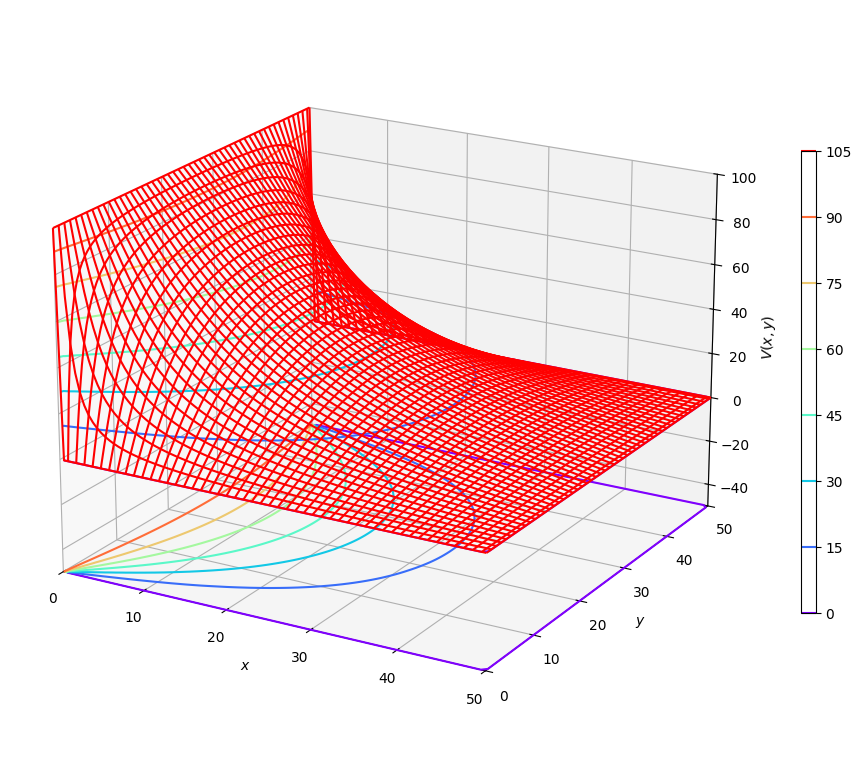

In [1]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt

# 设置参数
max_iter = 100                  # 最大迭代次数
L = 100                         # 网格的尺寸（L x L）
V = np.zeros((L, L))            # 初始化电势场矩阵

# 计算超松弛迭代法（SOR）中的松弛因子
omega = 2 / (1 + np.pi / L)     # 最优松弛因子，用于加速收敛

# 设置边界条件：左边界（第0列）电势为100V
V[:, 0] = 100.0

# 使用超松弛迭代法求解拉普拉斯方程
for _ in range(max_iter):
    for i in range(1, L - 1):       # 遍历内部点的x坐标
        for j in range(1, L - 1):   # 遍历内部点的y坐标
            # SOR迭代公式：基于周围四个点的平均值进行更新
            V[i, j] = (1 - omega) * V[i, j] + omega / 4 * (
                V[i + 1, j] + V[i - 1, j] + V[i, j + 1] + V[i, j - 1]
            )

# 生成网格坐标（假设物理空间为0到50单位）
x = np.linspace(0, 50, L)   # x轴坐标
y = np.linspace(0, 50, L)   # y轴坐标
X, Y = np.meshgrid(x, y)    # 将坐标转换为网格矩阵

# 绘制3D电势分布图
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection="3d")

# 绘制线框曲面图
ax.plot_wireframe(X, Y, V, color="r")
contour = ax.contour(X, Y, V, cmap="rainbow")
ax.contour(X, Y, V, zdir='z', offset=-50, cmap="rainbow")  # 在xy平面显示等值线
plt.colorbar(contour, shrink=0.5, aspect=30)

# 设置坐标轴标签
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$V(x,y)$")

# 设置坐标轴范围
ax.set_xlim(0, 50)
ax.set_ylim(0, 50)
ax.set_zlim(-50, 100)       # z轴范围调整以增强视觉效果

# 设置视角：仰角20度，方位角-60度
ax.view_init(elev=20, azim=-60)

# 显示图形
plt.show()